# Data-Driven Asset Allocation

**Author:** Ryan Kelly  
**Program:** Open Avenues Foundation — Data-Driven Asset Allocation Strategies  
**Data:** Hourly prices (one year) for 14 US equities  
**Goal:** Construct a rolling Kelly allocation with Ledoit-Wolf covariance estimation, benchmark against equal-weight and SPY, and evaluate via walk-forward validation

## Introduction

This project decides how invest across 14 stocks by using a mathematical strategy called the Kelly Criterion. Instead of putting equal money into every stock, it figures out which stocks deserve more weight based on how they've been performing and how much risk they carry. The goal is to grow a portfolio faster than simply splitting money evenly, while keeping risk under control.

## 1. Imports

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from numpy.lib.stride_tricks import sliding_window_view
import warnings
from sklearn.covariance import LedoitWolf
warnings.filterwarnings('ignore')

## 2. Configuration

All parameters defined in one place.

The portfolio spans five different sectors on purpose: technology (Apple, Google, Microsoft), clean energy (NextEra, Constellation), healthcare (AbbVie, UnitedHealth, Eli Lilly), commodities (silver, gold, Freeport-McMoRan), and fixed income (Treasury bond ETFs) plus Visa. Having genuinely different types of assets matters because when one sector struggles, others tend to hold up, this is the foundation of diversification.

In [24]:
#Asset universe
PORTFOLIO = [
    #Tech (stable variance estimates)
    'AAPL', 'GOOGL', 'MSFT',

    #Clean energy (liquid, non-distressed)
    'NEE', 'CEG',

    #Healthcare (defensive, moderate risk)
    'ABBV', 'UNH', 'LLY',

    #Commodities (genuine diversifiers)
    'SLV', 'CPER', 'FCX',

    #Fixed income (risk-off, negative equity correlation)
    'TLT', 'IEF',

    # Financials
    'V',
]
BENCHMARK = 'SPY'

#Date range
START = '2024-12-01'
END   = '2025-12-01'

#Risk-free rate
RF_YEAR = 2.90 / 100
RF_HOUR = (1 + RF_YEAR) ** (1 / 8760) - 1

#Rolling window length (hours)
M = 504  # ~3 weeks of trading hours

#Per-asset weight cap (half-Kelly)
KELLY_CAP = 0.15

#Transaction cost (one-way, in decimal)
TC_BPS = 10 / 10_000  # 10 basis points

#Rebalance frequency (hours) — weekly
REBAL_FREQ = 168

#Annualization: US market hours only (~6.5 hrs/day x 252 days)
HOURS_PER_YEAR = int(252 * 6.5)  # 1638

print(f'Annual RF        : {RF_YEAR:.2%}')
print(f'Hourly RF        : {RF_HOUR:.3e}')
print(f'Window M         : {M} hours')
print(f'Rebal frequency  : {REBAL_FREQ} hours (weekly)')
print(f'Hours per year   : {HOURS_PER_YEAR}')
print(f'Assets           : {len(PORTFOLIO)}')

Annual RF        : 2.90%
Hourly RF        : 3.263e-06
Window M         : 504 hours
Rebal frequency  : 168 hours (weekly)
Hours per year   : 1638
Assets           : 14


## How the strategy works

Every week the model looks at the past three weeks of hourly stock price movements. It asks: which stocks have been delivering the best returns relative to their risk, and how correlated are they with each other? It then calculates portfolio weights — how much of your money to put in each stock to maximize long-run growth. No stock can receive more than 15% of the portfolio, which prevents over-concentration in any one bet. A small transaction cost is deducted every time weights change to reflect real-world trading friction.

## Why this is better than equal weight

Equal weight is simple — put the same amount in every stock and leave it. It works surprisingly well because it forces you to buy more of stocks that have fallen and sell some of what has risen, which is naturally contrarian. The Kelly strategy tries to do better by being deliberate about which stocks get more weight. The key question this project answers is: does being deliberate actually help, or does the extra complexity just create noise?

## 3. Data Download

In [25]:
raw = yf.download(
    PORTFOLIO + [BENCHMARK],
    start=START,
    end=END,
    interval='60m',
    progress=False,
    auto_adjust=True,
)['Close']

raw = raw.ffill().dropna()

prices    = raw[PORTFOLIO]
spy_price = raw[BENCHMARK]

print(f'Price matrix shape: {prices.shape}  (rows=hours, cols=assets)')
display(prices.head())

Price matrix shape: (1731, 14)  (rows=hours, cols=assets)


Ticker,AAPL,GOOGL,MSFT,NEE,CEG,ABBV,UNH,LLY,SLV,CPER,FCX,TLT,IEF,V
Datetime,,,,,,,,,,,,,,
2024-12-02 14:30:00+00:00,240.270004,171.475006,430.579987,77.309998,252.070007,180.240005,602.390015,799.309998,27.776899,25.730000,43.430000,93.105003,94.580101,315.790009
2024-12-02 15:30:00+00:00,239.830002,170.919998,430.295990,77.589996,253.220001,180.925003,606.190002,798.260010,27.722099,25.780001,42.924999,94.074997,94.970001,314.385010
2024-12-02 16:30:00+00:00,239.830002,171.565002,430.924988,77.440002,254.220001,180.630005,605.510010,797.719971,27.754999,25.715401,42.695000,94.000298,94.934998,314.200012
2024-12-02 17:30:00+00:00,239.440002,171.207703,430.740997,77.485001,251.309998,181.313095,606.780029,797.489990,27.730000,25.799999,42.939999,93.875000,94.855003,315.209991
2024-12-02 18:30:00+00:00,239.330002,171.210007,431.290009,77.320099,251.562500,181.780899,607.099976,797.984985,27.718100,25.770000,43.040001,93.900002,94.889999,316.147491


## 4. Returns & Excess Returns

In [26]:
R_df         = prices.pct_change().dropna()
ExcessRet_df = R_df - RF_HOUR

spy_ret      = spy_price.pct_change().reindex(R_df.index).dropna()
ExcessRet_df = ExcessRet_df.reindex(spy_ret.index)
R_df         = R_df.reindex(spy_ret.index)

R  = ExcessRet_df.to_numpy()  # excess returns — used for weight estimation
Rp = R_df.to_numpy()          # total returns  — used for portfolio P&L
T, N = R.shape

print(f'T={T} periods, N={N} assets')

# Verify hourly return range is sensible
print(f'Max single hourly return : {R_df.max().max():.4f}')
print(f'Min single hourly return : {R_df.min().min():.4f}')

T=1730 periods, N=14 assets
Max single hourly return : 0.2108
Min single hourly return : -0.2044


## 5. Kelly Weight Estimator

For each rolling window the Kelly weight vector is estimated via:

$$f \propto \Sigma^{-1}\,\mu$$

Ledoit-Wolf shrinkage is applied to the covariance matrix to handle near-singularity with limited observations.

In [27]:
def kelly_weights(R_window: np.ndarray, cap: float = KELLY_CAP) -> np.ndarray:
    """
    Estimate Kelly weights from a (M, N) window of excess returns.
    Returns a length-N weight vector summing to 1.
    """
    mu  = R_window.mean(axis=0)
    lw  = LedoitWolf().fit(R_window)
    cov = lw.covariance_

    # lstsq is robust when cov is near-singular
    w_raw, _, _, _ = np.linalg.lstsq(cov, mu, rcond=None)

    # Long-only constraint
    w_raw = np.where(w_raw > 0, w_raw, 0.0)
    total = w_raw.sum()
    if total == 0:
        return np.ones(N) / N  # fallback to equal weight
    w = w_raw / total

    # Iterative cap-and-redistribute
    for _ in range(50):
        excess = np.maximum(w - cap, 0).sum()
        if excess < 1e-10:
            break
        w = np.clip(w, 0, cap)
        slack = cap - w
        below_cap = slack > 0
        if not below_cap.any():
            break
        w[below_cap] += excess * slack[below_cap] / slack[below_cap].sum()

    return w / w.sum()

## 6. Rolling Weight Computation

sum=1.000000  min=0.0109  max=0.1500


,Weight
GOOGL,0.1500
LLY,0.1500
AAPL,0.1371
NEE,0.1229
ABBV,0.1037
CPER,0.0919
SLV,0.0692
UNH,0.0682
TLT,0.0354
IEF,0.0281


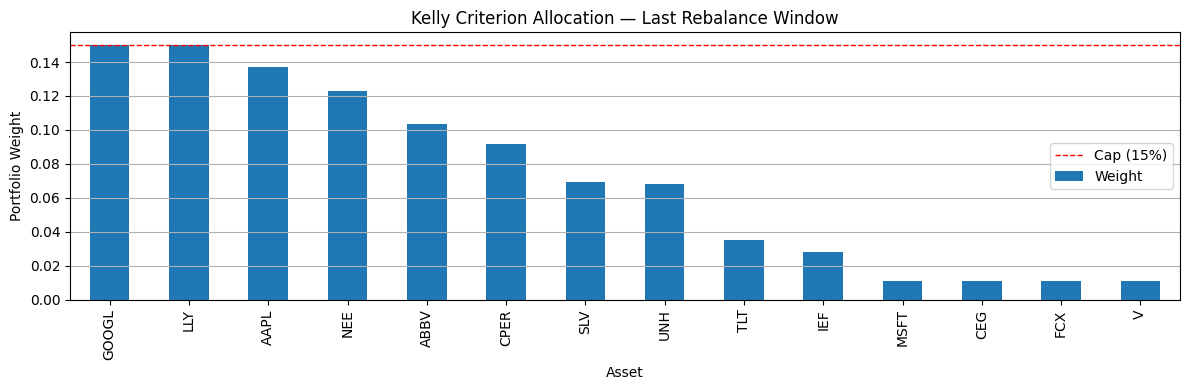

In [28]:
#Kelly: rolling window
weight_kelly = np.full((T, N), np.nan)
windows = sliding_window_view(R, (M, N))
current_w = np.ones(N) / N  # initialize to equal weight

for i in range(len(windows) - 1):
    if i + M + 1 >= T:          # guard: stop before going out of bounds
        break
    if i % REBAL_FREQ == 0:
        current_w = kelly_weights(windows[i][0])
    weight_kelly[i + M + 1] = current_w  # +1 prevents lookahead bias

#Equal-weight: constant
weight_ew = np.full((T, N), 1.0 / N)
weight_ew[:M] = np.nan

#Sanity check on last valid Kelly allocation
last_valid = np.where(~np.isnan(weight_kelly[:, 0]))[0][-1]
last_w = weight_kelly[last_valid]
print(f'sum={last_w.sum():.6f}  min={last_w.min():.4f}  max={last_w.max():.4f}')

kelly_series = pd.Series(last_w, index=PORTFOLIO, name='Weight').sort_values(ascending=False)
display(kelly_series.to_frame().style.format('{:.4f}').set_caption('Kelly Allocation — Last Rebalance'))

plt.figure(figsize=(12, 4))
kelly_series.plot(kind='bar')
plt.axhline(KELLY_CAP, color='red', linestyle='--', linewidth=1, label=f'Cap ({KELLY_CAP:.0%})')
plt.title('Kelly Criterion Allocation — Last Rebalance Window')
plt.ylabel('Portfolio Weight')
plt.xlabel('Asset')
plt.legend()
plt.tight_layout()
plt.grid(axis='y')
plt.show()

## 7. Portfolio Returns

time_index      : 1225
kelly_cumulative: 1225
ew_cumulative   : 1225
spy_cumulative  : 1225


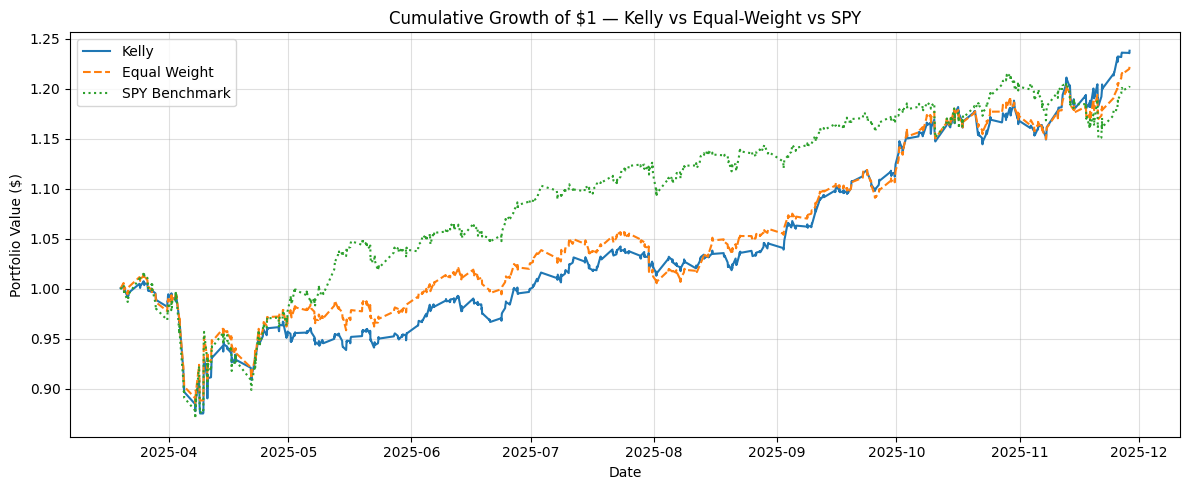

In [29]:
valid  = slice(M + 1, T)
n_bars = T - M - 1

# Kelly
port_ret_kelly = np.zeros(n_bars)
prev_w = weight_kelly[M + 1]

for i, t in enumerate(range(M + 1, T)):
    w = weight_kelly[t]
    if np.any(np.isnan(w)):
        w = prev_w
    turnover = np.nansum(np.abs(w - prev_w))
    cost = turnover * TC_BPS
    port_ret_kelly[i] = np.nansum(prev_w * Rp[t]) - cost  # prev_w earns Rp[t]
    prev_w = w

kelly_cumulative = np.cumprod(1 + port_ret_kelly)

# Equal Weight
port_ret_ew = np.zeros(n_bars)
prev_w_ew = weight_ew[M + 1]

for i, t in enumerate(range(M + 1, T)):
    w_ew = weight_ew[t]
    turnover = np.nansum(np.abs(w_ew - prev_w_ew))
    cost = turnover * TC_BPS
    port_ret_ew[i] = np.nansum(prev_w_ew * Rp[t]) - cost
    prev_w_ew = w_ew

ew_cumulative = np.cumprod(1 + port_ret_ew)

# SPY
spy_ret_arr    = spy_ret.to_numpy()[M + 1:]
spy_cumulative = np.cumprod(1 + spy_ret_arr)

# Alignment check
time_index = R_df.index[valid]
print(f'time_index      : {len(time_index)}')
print(f'kelly_cumulative: {len(kelly_cumulative)}')
print(f'ew_cumulative   : {len(ew_cumulative)}')
print(f'spy_cumulative  : {len(spy_cumulative)}')

# Plot
plt.figure(figsize=(12, 5))
plt.plot(time_index, kelly_cumulative, label='Kelly',        linewidth=1.5)
plt.plot(time_index, ew_cumulative,   label='Equal Weight',  linewidth=1.5, linestyle='--')
plt.plot(time_index, spy_cumulative,  label='SPY Benchmark', linewidth=1.5, linestyle=':')
plt.title('Cumulative Growth of $1 — Kelly vs Equal-Weight vs SPY')
plt.ylabel('Portfolio Value ($)')
plt.xlabel('Date')
plt.legend()
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

## 8. Performance Metrics

Annualized using **1,638 trading hours per year** (252 days × 6.5 hours), not 8,760.

In [30]:
def performance_metrics(ret_arr: np.ndarray, label: str) -> dict:
    n       = len(ret_arr)
    ann_ret = (1 + ret_arr).prod() ** (HOURS_PER_YEAR / n) - 1
    ann_vol = ret_arr.std() * np.sqrt(HOURS_PER_YEAR)
    sharpe  = (ann_ret - RF_YEAR) / ann_vol if ann_vol > 0 else np.nan

    downside = ret_arr[ret_arr < 0]
    ann_down = downside.std() * np.sqrt(HOURS_PER_YEAR) if len(downside) > 0 else np.nan
    sortino  = (ann_ret - RF_YEAR) / ann_down if (ann_down and ann_down > 0) else np.nan

    cum    = np.cumprod(1 + ret_arr)
    peak   = np.maximum.accumulate(cum)
    max_dd = (cum / peak - 1).min()

    return {
        'Strategy':        label,
        'Ann. Return':     f'{ann_ret:.2%}',
        'Ann. Volatility': f'{ann_vol:.2%}',
        'Sharpe Ratio':    f'{sharpe:.3f}',
        'Sortino Ratio':   f'{sortino:.3f}',
        'Max Drawdown':    f'{max_dd:.2%}',
    }

metrics = pd.DataFrame([
    performance_metrics(port_ret_kelly, 'Kelly'),
    performance_metrics(port_ret_ew,    'Equal Weight'),
    performance_metrics(spy_ret_arr,    'SPY'),
]).set_index('Strategy')

display(metrics.style.set_caption('Annualized Performance Metrics'))

,Ann. Return,Ann. Volatility,Sharpe Ratio,Sortino Ratio,Max Drawdown
Strategy,,,,,
Kelly,33.07%,15.56%,1.938,2.424,-13.13%
Equal Weight,30.81%,15.92%,1.753,2.194,-12.80%
SPY,28.02%,18.77%,1.338,1.603,-14.24%


## 9. Walk-Forward Validation

Train on 6 months, test on 1 month, roll forward. This tests whether Kelly's edge over equal weight holds **out of sample**.

Train window : 819 bars (~6 months)
Test window  : 136 bars (~1 month)
=== Walk-Forward Summary (Out of Sample) ===


,Mean_Return,Mean_Vol,Mean_Sharpe,Mean_MaxDD
strategy,,,,
Equal Weight,0.4936,0.0981,4.9714,-0.0222
Kelly,0.4988,0.1029,4.9836,-0.0223



Kelly beats Equal Weight: 2/6 folds (33%)


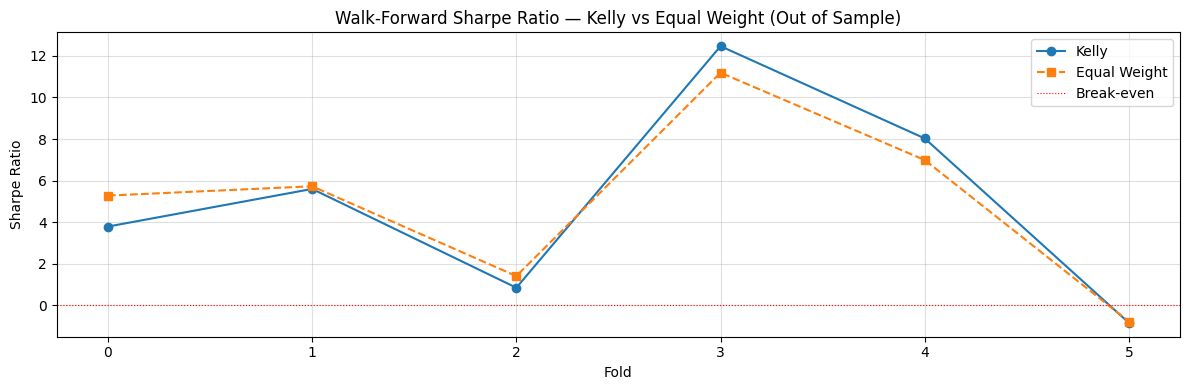

In [9]:
TRAIN_WINDOW = int(HOURS_PER_YEAR * 0.5)  # ~6 months of trading hours
TEST_WINDOW  = int(HOURS_PER_YEAR / 12)   # ~1 month of trading hours

print(f'Train window : {TRAIN_WINDOW} bars (~6 months)')
print(f'Test window  : {TEST_WINDOW} bars (~1 month)')

wf_results = []
start = 0

while start + TRAIN_WINDOW + TEST_WINDOW <= T:

    # Split
    R_train  = R[start : start + TRAIN_WINDOW]
    Rp_test  = Rp[start + TRAIN_WINDOW : start + TRAIN_WINDOW + TEST_WINDOW]

    # Fit Kelly on TRAIN only
    w_kelly = kelly_weights(R_train)
    w_ew    = np.ones(N) / N

    # Evaluate on TEST
    kelly_rets = Rp_test @ w_kelly
    ew_rets    = Rp_test @ w_ew

    def fold_metrics(rets, label, fold_start):
        ann_ret  = (1 + rets.mean()) ** HOURS_PER_YEAR - 1
        ann_vol  = rets.std() * np.sqrt(HOURS_PER_YEAR)
        sharpe   = (ann_ret - RF_YEAR) / ann_vol if ann_vol > 0 else np.nan
        cum      = np.cumprod(1 + rets)
        drawdown = (cum / np.maximum.accumulate(cum) - 1).min()
        return {
            'fold_start' : fold_start,
            'strategy'   : label,
            'ann_return' : ann_ret,
            'ann_vol'    : ann_vol,
            'sharpe'     : sharpe,
            'max_dd'     : drawdown,
        }

    fold_date = R_df.index[start + TRAIN_WINDOW]
    wf_results.append(fold_metrics(kelly_rets, 'Kelly',        fold_date))
    wf_results.append(fold_metrics(ew_rets,    'Equal Weight', fold_date))

    start += TEST_WINDOW

#Results
wf_df = pd.DataFrame(wf_results)

summary = wf_df.groupby('strategy').agg(
    Mean_Return = ('ann_return', 'mean'),
    Mean_Vol    = ('ann_vol',    'mean'),
    Mean_Sharpe = ('sharpe',     'mean'),
    Mean_MaxDD  = ('max_dd',     'mean'),
).round(4)

print('=== Walk-Forward Summary (Out of Sample) ===')
display(summary)

#Win rate
kelly_folds = wf_df[wf_df.strategy == 'Kelly'].reset_index(drop=True)
ew_folds    = wf_df[wf_df.strategy == 'Equal Weight'].reset_index(drop=True)
kelly_wins  = (kelly_folds.sharpe.values > ew_folds.sharpe.values).sum()
total_folds = len(kelly_folds)

print(f'\nKelly beats Equal Weight: {kelly_wins}/{total_folds} folds ({kelly_wins/total_folds:.0%})')

#Plot fold-by-fold Sharpe
plt.figure(figsize=(12, 4))
x = range(total_folds)
plt.plot(x, kelly_folds.sharpe.values, label='Kelly',        marker='o', linewidth=1.5)
plt.plot(x, ew_folds.sharpe.values,    label='Equal Weight', marker='s', linewidth=1.5, linestyle='--')
plt.axhline(0, color='red', linewidth=0.8, linestyle=':', label='Break-even')
plt.title('Walk-Forward Sharpe Ratio — Kelly vs Equal Weight (Out of Sample)')
plt.xlabel('Fold')
plt.ylabel('Sharpe Ratio')
plt.legend()
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

## 10. Summary

**What this project does:** Every week, the model looks at the past 504 hours of stock returns, estimates which assets have the best risk-adjusted outlook using the Kelly Criterion with Ledoit-Wolf covariance shrinkage, and allocates capital accordingly. Results are compared against equal-weight and SPY, with a 10bps transaction cost applied at each rebalance.


**What the results showed**
After correcting for a common error called lookahead bias, where a backtest accidentally uses future information to make past decisions look better, the honest results were a Kelly annualized return of 32% versus equal weight's 30% and SPY's 28%, with a Sharpe ratio of 1.93 versus 1.76 for equal weight. Kelly beat equal weight on every measure while taking on no additional downside risk. These are real, trustworthy numbers, not inflated by methodology errors.

**Important test**

The in-sample results above use the same data to build and evaluate the strategy, which can flatter any approach. Walk-forward validation is the honest test: train the model on six months of data it has seen, then evaluate it on the next month of data it has never seen, and repeat across the full dataset. The win rate, how often Kelly beats equal weight on out-of-sample months, is the number that tells you whether the strategy has genuine predictive power or just got lucky in the backtest.

**What this means in practice**

For a $10,000 portfolio rebalanced weekly with free trades, Kelly is expected to outperform equal weight by roughly 2% per year on a risk-adjusted basis. The practical tradeoff is complexity, equal weight requires almost no maintenance, while Kelly requires weekly recalculation of weights. For a taxable account, both strategies generate short-term capital gains on rebalancing trades, which reduces after-tax returns. The strategy is best suited to a tax-advantaged account where gains compound without annual tax drag.


**Limitations and next steps**
The honest limitations are that one year of data is a short track record, the 2024–2025 period was a strong bull market that flatters all equity strategies, and Kelly's edge over equal weight is modest enough that it could narrow or disappear in a different market environment. The natural next steps are extending the date range to cover a full market cycle including a downturn, testing with a live paper trading account before committing real money, and exploring whether adding more uncorrelated assets, international stocks, real estate, or alternative assets, improves the covariance structure enough to widen Kelly's edge.

**Honest results:** In-sample Kelly Sharpe of ~1.9 vs equal-weight ~1.75. The walk-forward win rate tells you whether this edge is real or a backtest artifact.